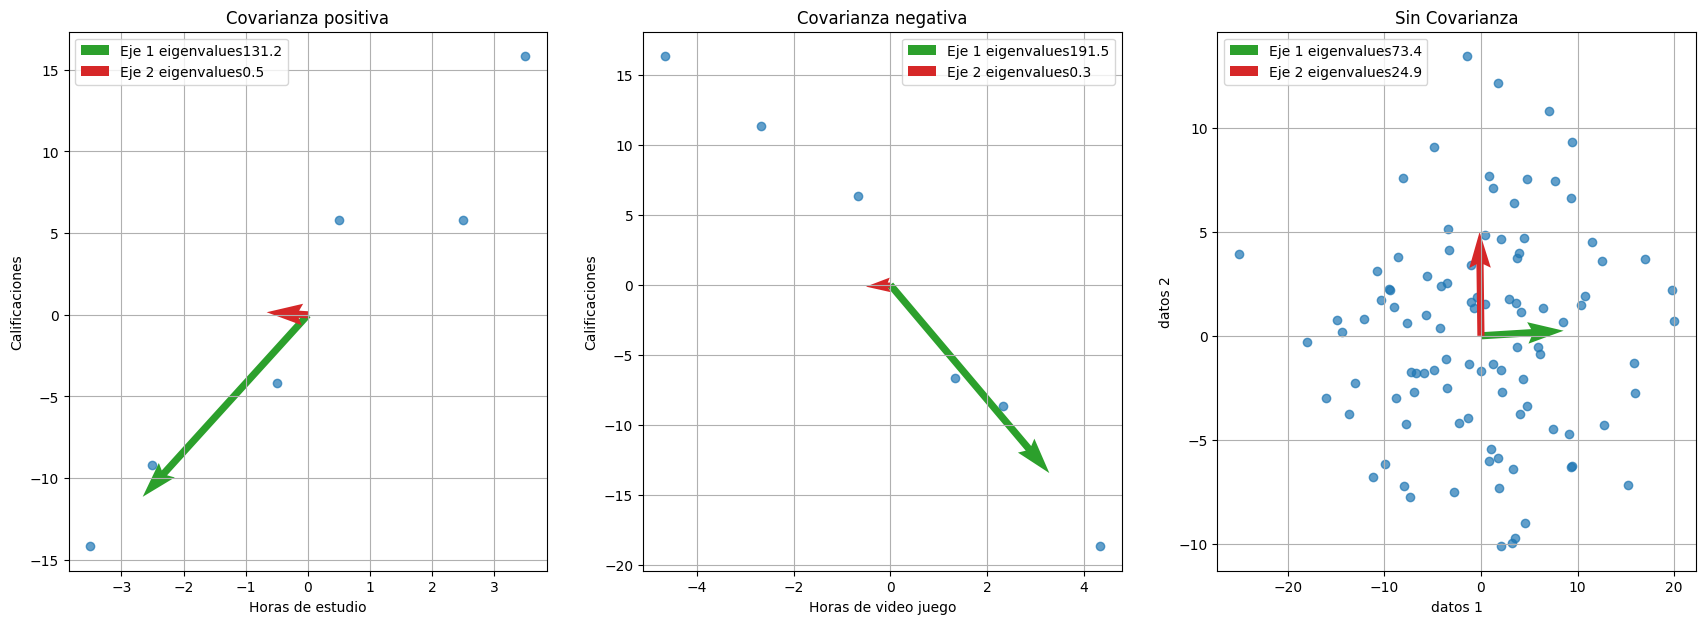

covarianza positiva
[[  7.5         29.5       ]
 [ 29.5        124.16666667]]
covarianza negativa
[[ 11.06666667 -44.13333333]
 [-44.13333333 180.66666667]]
covarianza cero
[[73.32723151  1.38231034]
 [ 1.38231034 24.94296043]]


In [9]:
import numpy as np
import matplotlib.pyplot as plt

def analizar_graficar(ax, datos, titulo, features):
  matriz_cov = np.cov(datos, rowvar=False)
  eigenvalues, eigenvectors = np.linalg.eig(matriz_cov)

  idx = np.argsort(eigenvalues)[::-1] # ordena de mayor a menor
  eigenvalues = eigenvalues[idx] # ordena el vector de eigenvalues
  eigenvectors = eigenvectors[:,idx] # ordena la matriz de eingenvectors

  datos_centrados = datos - np.mean(datos, axis=0)
  ax.scatter(datos_centrados[:,0], datos_centrados[:,1], alpha = 0.7)

  for i in range(len(eigenvalues)):
    eigenvec = eigenvectors[:,i]
    length = np.sqrt(eigenvalues[i])
    ax.quiver(0,0, eigenvec[0]*length, eigenvec[1]*length, angles = "xy", scale_units = "xy", scale = 1, color = f"C{i+2}", width = 0.015, label = f"Eje {i+1} eigenvalues{eigenvalues[i]:.1f}")

  ax.set_title(titulo)
  ax.set_xlabel(features[0])
  ax.set_ylabel(features[1])
  ax.grid(True)
  ax.legend()

  return matriz_cov

datos_pos = np.array([
  [2,65],
  [3,70],
  [5,75],
  [6,85],
  [8,85],
  [9,95]
])

datos_neg = np.array([
  [10,60],
  [8,70],
  [7,72],
  [5,85],
  [3,90],
  [1,95]
])

np.random.seed(42)

datos_cero = np.random.randn(100,2)*np.array([10.0 , 5.0])

fig, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(21,7))

cov_pos = analizar_graficar(ax1, datos_pos, "Covarianza positiva", ["Horas de estudio", "Calificaciones"])
cov_neg = analizar_graficar(ax2, datos_neg, "Covarianza negativa", ["Horas de video juego", "Calificaciones"])
cov_cero = analizar_graficar(ax3, datos_cero, "Sin Covarianza", ["datos 1", "datos 2"])

plt.show()

print("covarianza positiva")
print(cov_pos)
print("covarianza negativa")
print(cov_neg)
print("covarianza cero")
print(cov_cero)










